In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

plt.rcParams["figure.figsize"]=(14,6)
sns.set_style("whitegrid")

In [2]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [4]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


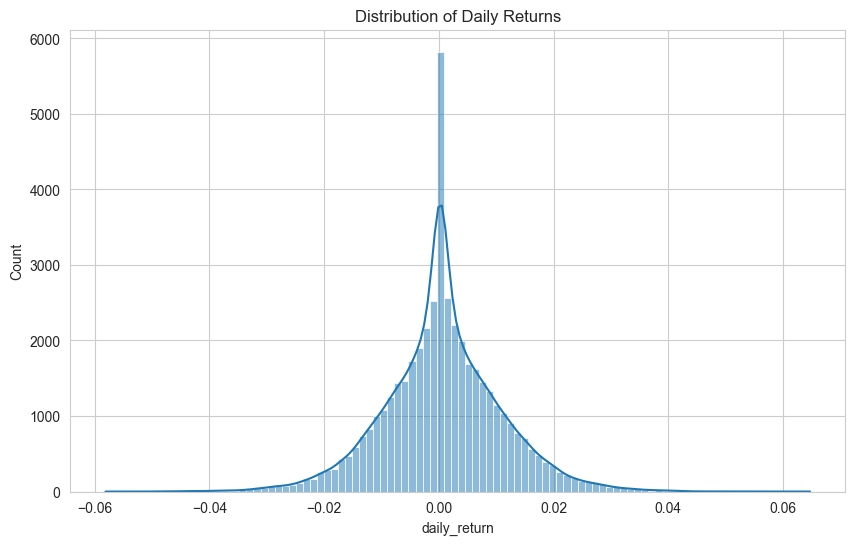

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.savefig("../charts/daily_return_distribution.png")

plt.show()

## Insight 1

Daily returns are concentrated around zero with relatively few extreme positive or negative movements, indicating a realistic distribution of mutual fund returns.

In [6]:
cagr=[]

for code in nav["amfi_code"].unique():

    df=nav[nav["amfi_code"]==code]

    start=df.iloc[0]["nav"]
    end=df.iloc[-1]["nav"]

    years=(df["date"].max()-df["date"].min()).days/365.25

    value=((end/start)**(1/years)-1)*100

    cagr.append([code,value])

cagr_df=pd.DataFrame(cagr,columns=["amfi_code","CAGR"])

cagr_df.head()

,amfi_code,CAGR
0,100016,2.637074
1,100025,4.458210
2,100033,30.123153
3,101206,23.538361
4,101207,7.938765


In [7]:
cagr_df.to_csv("../reports/cagr.csv",index=False)

In [8]:
rf = 0.065

sharpe = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code]

    returns = df["daily_return"].dropna()

    if len(returns) > 0:

        annual_return = returns.mean() * 252
        annual_std = returns.std() * np.sqrt(252)

        sharpe_ratio = (annual_return - rf) / annual_std

        sharpe.append([code, sharpe_ratio])

sharpe_df = pd.DataFrame(sharpe, columns=["amfi_code", "Sharpe_Ratio"])

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [9]:
sharpe_df.to_csv("../reports/sharpe_ratio.csv", index=False)

In [10]:
sortino = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code]

    returns = df["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 0:

        annual_return = returns.mean() * 252
        downside_std = downside.std() * np.sqrt(252)

        ratio = (annual_return - rf) / downside_std

        sortino.append([code, ratio])

sortino_df = pd.DataFrame(sortino, columns=["amfi_code", "Sortino_Ratio"])

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [11]:
nifty = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty = nifty.sort_values("date")

nifty["benchmark_return"] = nifty["close_value"].pct_change()

In [12]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].copy()

    merged = pd.merge(
        df,
        nifty[["date", "benchmark_return"]],
        on="date"
    )

    merged = merged.dropna()

    if len(merged) > 20:

        slope, intercept, r, p, std = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append([code, alpha, beta])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=["amfi_code", "Alpha", "Beta"]
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [13]:
alpha_beta_df.to_csv("../reports/alpha_beta.csv", index=False)

In [14]:
drawdown = []

for code in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == code].copy()

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = df["nav"] / df["running_max"] - 1

    max_dd = df["drawdown"].min()

    drawdown.append([code, max_dd])

drawdown_df = pd.DataFrame(
    drawdown,
    columns=["amfi_code", "Max_Drawdown"]
)

drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [15]:
drawdown_df.to_csv("../reports/max_drawdown.csv", index=False)

In [16]:
score = (
    sharpe_df
    .merge(alpha_beta_df, on="amfi_code")
    .merge(drawdown_df, on="amfi_code")
)

score["Score"] = (
    score["Sharpe_Ratio"].rank(pct=True) * 25 +
    score["Alpha"].rank(pct=True) * 20 +
    (-score["Max_Drawdown"]).rank(pct=True) * 10
)

score = score.sort_values("Score", ascending=False)

score.head()

,amfi_code,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,Score
25,120505,1.180101,0.292636,0.000549,-0.181885,47.750
36,148569,1.234930,0.282704,0.018134,-0.163967,47.500
39,149324,0.949796,0.300579,0.011455,-0.311719,46.250
21,119598,0.945308,0.303370,-0.023196,-0.287060,45.875
30,120843,1.306744,0.273305,-0.022830,-0.129740,45.625


In [17]:
score.to_csv("../reports/fund_scorecard.csv", index=False)

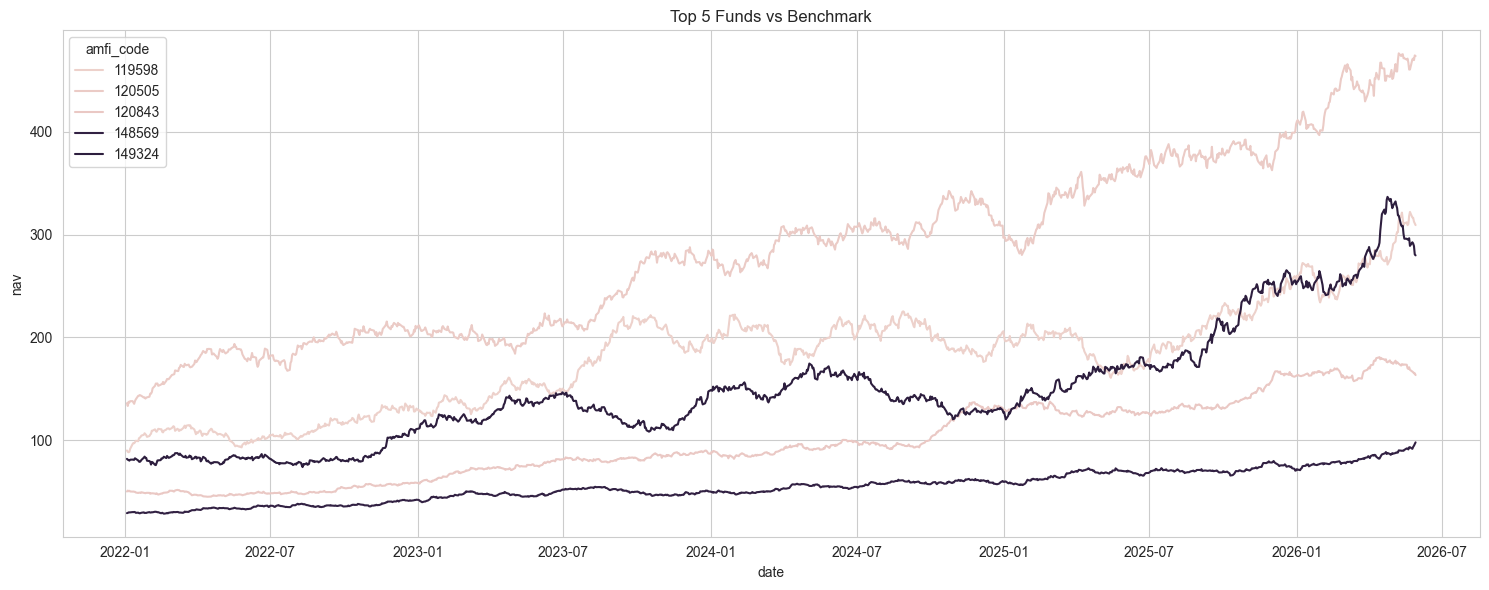

In [18]:
top5 = score.head(5)["amfi_code"]

compare = nav[nav["amfi_code"].isin(top5)]

plt.figure(figsize=(15,6))

sns.lineplot(
    data=compare,
    x="date",
    y="nav",
    hue="amfi_code"
)

plt.title("Top 5 Funds vs Benchmark")

plt.tight_layout()

plt.savefig("../charts/benchmark_comparison.png", dpi=300)

plt.show()

In [19]:
sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [20]:
sortino_df.to_csv("../reports/sortino_ratio.csv", index=False)

In [22]:
import pandas as pd

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

In [23]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [24]:
fund.to_csv("../data/processed/01_fund_master.csv", index=False)
aum.to_csv("../data/processed/03_aum_by_fund_house.csv", index=False)
sip.to_csv("../data/processed/04_monthly_sip_inflows.csv", index=False)
category.to_csv("../data/processed/05_category_inflows.csv", index=False)
folio.to_csv("../data/processed/06_industry_folio_count.csv", index=False)
portfolio.to_csv("../data/processed/09_portfolio_holdings.csv", index=False)
benchmark.to_csv("../data/processed/10_benchmark_indices.csv", index=False)